<a href="https://colab.research.google.com/github/varshithkuravati/ML-practice/blob/main/gps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/onyekpeu/IO-VNBD.git
%cd IO-VNBD
!unzip -q "Synchronised V abd S datasets.zip" -d ./data_sync

Cloning into 'IO-VNBD'...
remote: Enumerating objects: 618, done.
remote: Counting objects: 100% (618/618), done.
remote: Compressing objects: 100% (615/615), done.
remote: Total 618 (delta 2), reused 608 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (618/618), 1.01 MiB | 14.51 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Filtering content: 100% (566/566), 2.06 GiB | 58.15 MiB/s, done.
/content/IO-VNBD


In [2]:
import shutil
shutil.rmtree('/content/IO-VNBD/data_sync/Synchronised V abd S datasets')

In [3]:
import os
import shutil
import glob
import numpy as np

# Define target dataset folders
base_dir = '/content/IO-VNBD/data_sync'
folders = ['train', 'val', 'test']

for folder in folders:
    os.makedirs(os.path.join(base_dir, folder), exist_ok=True)

# Find all smartphone files and extract matching run IDs
s_files = sorted(glob.glob('/content/IO-VNBD/data_sync/S-Dataset/S-*.csv'))

# Collect matching paired IDs (e.g., ID '1' from 'S-1.csv' and 'V-1.csv')
paired_ids = []
for s_path in s_files:
    file_id = os.path.basename(s_path).replace('S-', '').replace('.csv', '')
    v_path = f'/content/IO-VNBD/data_sync/V-Dataset/V-{file_id}.csv'
    if os.path.exists(v_path):
        paired_ids.append(file_id)

# Shuffle paired IDs reproducibly
np.random.seed(42)
np.random.shuffle(paired_ids)

# Calculate split sizes
n_total = len(paired_ids)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

train_ids = paired_ids[:n_train]
val_ids = paired_ids[n_train:n_train + n_val]
test_ids = paired_ids[n_train + n_val:]

def copy_pairs(id_list, target_folder):
    for run_id in id_list:
        shutil.copy(f'/content/IO-VNBD/data_sync/S-Dataset/S-{run_id}.csv', f'{base_dir}/{target_folder}/S-{run_id}.csv')
        shutil.copy(f'/content/IO-VNBD/data_sync/V-Dataset/V-{run_id}.csv', f'{base_dir}/{target_folder}/V-{run_id}.csv')

copy_pairs(train_ids, 'train')
copy_pairs(val_ids, 'val')
copy_pairs(test_ids, 'test')

print(f"Dataset split complete:")
print(f" - Train runs: {len(train_ids)}")
print(f" - Val runs:   {len(val_ids)}")
print(f" - Test runs:  {len(test_ids)}")

Dataset split complete:
 - Train runs: 22
 - Val runs:   4
 - Test runs:  6


diagonisis test

In [ ]:
import glob
import os
import numpy as np
import pandas as pd

def run_deep_diagnostics(train_dir, val_dir, dt=0.1):
    def inspect_folder(folder_path):
        s_files = sorted(glob.glob(os.path.join(folder_path, 'S-*.csv')))
        run_stats = []

        for s_path in s_files:
            run_id = os.path.basename(s_path).replace('S-', '').replace('.csv', '')
            v_path = os.path.join(folder_path, f'V-{run_id}.csv')
            if not os.path.exists(v_path):
                continue

            df_imu = pd.read_csv(s_path, encoding='latin1').ffill().bfill()
            df_veh = pd.read_csv(v_path, encoding='latin1').ffill().bfill()

            min_len = min(len(df_imu), len(df_veh))
            df_imu, df_veh = df_imu.iloc[:min_len], df_veh.iloc[:min_len]

            # Extract Signals
            ax = (df_imu.iloc[:, 9] - df_imu.iloc[:, 12]).values
            v_kmh = df_veh.iloc[:, 4].values
            v_ms = v_kmh / 3.6

            # Kinematic physical integration (Raw integration delta v over 100 frames)
            window_size = 100
            imu_dv_100, true_dv_100 = [], []
            for i in range(0, min_len - window_size, 10):
                imu_dv_100.append(np.sum(ax[i : i + window_size]) * dt)
                true_dv_100.append(v_ms[i + window_size] - v_ms[i])

            corr = np.corrcoef(imu_dv_100, true_dv_100)[0, 1] if len(imu_dv_100) > 1 else np.nan

            run_stats.append({
                'run_id': run_id,
                'ax_mean': ax.mean(),
                'ax_std': ax.std(),
                'v_mean_kmh': v_kmh.mean(),
                'v_std_kmh': v_kmh.std(),
                'zero_speed_pct': (v_kmh < 0.5).mean() * 100,
                'imu_target_corr': corr
            })
        return pd.DataFrame(run_stats)

    df_train = inspect_folder(train_dir)
    df_val = inspect_folder(val_dir)

    print("=== 1. COVARIATE SHIFT CHECK (Train vs Val Means) ===")
    print(f"Train Accel Mean: {df_train['ax_mean'].mean():.4f} | Val Accel Mean: {df_val['ax_mean'].mean():.4f}")
    print(f"Train Speed Mean: {df_train['v_mean_kmh'].mean():.2f} km/h | Val Speed Mean: {df_val['v_mean_kmh'].mean():.2f} km/h")
    print(f"Train Zero-Speed %: {df_train['zero_speed_pct'].mean():.1f}% | Val Zero-Speed %: {df_val['zero_speed_pct'].mean():.1f}%\n")

    print("=== 2. KINEMATIC INTEGRATION CORRELATION (Physical Upper Bound) ===")
    print(f"Train Avg IMU-to-Target Corr: {df_train['imu_target_corr'].mean():.3f}")
    print(f"Val Avg IMU-to-Target Corr:   {df_val['imu_target_corr'].mean():.3f}\n")

    # Check for problematic runs in Validation set
    bad_val_runs = df_val[df_val['imu_target_corr'] < 0.3]
    if not bad_val_runs.empty:
        print("=== 3. DETECTED CORRUPTED/DESYNCED VAL RUNS ===")
        print(bad_val_runs[['run_id', 'imu_target_corr', 'v_mean_kmh']].to_string(index=False))

run_deep_diagnostics('/content/IO-VNBD/data_sync/train', '/content/IO-VNBD/data_sync/val')

In [ ]:
import glob
import os
import numpy as np
import pandas as pd

def fix_alignment_and_lag(dataset_dir, expected_dt=0.1, max_lag_steps=50):
    s_files = sorted(glob.glob(os.path.join(dataset_dir, 'S-*.csv')))

    results = []

    for s_path in s_files:
        run_id = os.path.basename(s_path).replace('S-', '').replace('.csv', '')
        v_path = os.path.join(dataset_dir, f'V-{run_id}.csv')
        if not os.path.exists(v_path):
            continue

        df_imu = pd.read_csv(s_path, encoding='latin1').ffill().bfill()
        df_veh = pd.read_csv(v_path, encoding='latin1').ffill().bfill()

        min_len = min(len(df_imu), len(df_veh))
        df_imu, df_veh = df_imu.iloc[:min_len], df_veh.iloc[:min_len]

        # Extract potential forward dynamic acceleration axes
        ax_dyn = (df_imu.iloc[:, 9] - df_imu.iloc[:, 12]).values
        ay_dyn = (df_imu.iloc[:, 10] - df_imu.iloc[:, 13]).values
        az_dyn = (df_imu.iloc[:, 11] - df_imu.iloc[:, 14]).values

        # Ground-truth vehicle acceleration (derivative of target velocity)
        v_ms = (df_veh.iloc[:, 4].values / 3.6)
        veh_accel = np.gradient(v_ms, expected_dt)

        # 1. Determine best forward axis via max correlation
        corr_x = np.corrcoef(ax_dyn, veh_accel)[0, 1]
        corr_y = np.corrcoef(ay_dyn, veh_accel)[0, 1]
        corr_z = np.corrcoef(az_dyn, veh_accel)[0, 1]

        corrs = {'ax': abs(corr_x), 'ay': abs(corr_y), 'az': abs(corr_z)}
        best_axis = max(corrs, key=corrs.get)
        best_accel = {'ax': ax_dyn, 'ay': ay_dyn, 'az': az_dyn}[best_axis]

        # 2. Compute time lag via cross-correlation shift (-5s to +5s)
        lags = range(-max_lag_steps, max_lag_steps + 1)
        cross_corrs = []

        for lag in lags:
            if lag < 0:
                c = np.corrcoef(best_accel[-lag:], veh_accel[:lag])[0, 1]
            elif lag > 0:
                c = np.corrcoef(best_accel[:-lag], veh_accel[lag:])[0, 1]
            else:
                c = np.corrcoef(best_accel, veh_accel)[0, 1]
            cross_corrs.append(c)

        optimal_lag_steps = lags[np.argmax(cross_corrs)]
        optimal_corr = np.max(cross_corrs)

        results.append({
            'run_id': run_id,
            'best_forward_axis': best_axis,
            'raw_corr': corrs[best_axis],
            'time_lag_sec': optimal_lag_steps * expected_dt,
            'fixed_corr': optimal_corr
        })

    return pd.DataFrame(results)

df_fixes = fix_alignment_and_lag('/content/IO-VNBD/data_sync/train')
print(df_fixes.to_string(index=False))

In [ ]:
import glob
import os
import numpy as np
import pandas as pd

def get_clean_dataset_manifest(dataset_dir, min_corr_threshold=0.20, dt=0.1):
    s_files = sorted(glob.glob(os.path.join(dataset_dir, 'S-*.csv')))
    valid_runs = []

    for s_path in s_files:
        run_id = os.path.basename(s_path).replace('S-', '').replace('.csv', '')
        v_path = os.path.join(dataset_dir, f'V-{run_id}.csv')
        if not os.path.exists(v_path):
            continue

        df_imu = pd.read_csv(s_path, encoding='latin1').ffill().bfill()
        df_veh = pd.read_csv(v_path, encoding='latin1').ffill().bfill()

        min_len = min(len(df_imu), len(df_veh))
        df_imu, df_veh = df_imu.iloc[:min_len], df_veh.iloc[:min_len]

        # 1. Calculate 3D Dynamic Acceleration Magnitude (Orientation Invariant)
        ax = df_imu.iloc[:, 9] - df_imu.iloc[:, 12]
        ay = df_imu.iloc[:, 10] - df_imu.iloc[:, 13]
        az = df_imu.iloc[:, 11] - df_imu.iloc[:, 14]
        a_mag = np.sqrt(ax**2 + ay**2 + az**2).values

        # 2. Vehicle Target Acceleration Derivative
        v_ms = df_veh.iloc[:, 4].values / 3.6
        veh_accel = np.abs(np.gradient(v_ms, dt))

        corr = np.corrcoef(a_mag, veh_accel)[0, 1]

        # Keep only runs that obey basic laws of physics
        if corr >= min_corr_threshold:
            valid_runs.append(run_id)
        else:
            print(f"DROPPING CORRUPT RUN: {run_id} (Corr: {corr:.3f})")

    return valid_runs

clean_train_runs = get_clean_dataset_manifest('/content/IO-VNBD/data_sync/train', min_corr_threshold=0.15)
print(f"\nUsable Training Runs ({len(clean_train_runs)} files): {clean_train_runs}")

In [ ]:
import glob
import os
import numpy as np
import pandas as pd

def diagnose_full_feature_set(dataset_dir, dt=0.1, max_lag_steps=50):
    s_files = sorted(glob.glob(os.path.join(dataset_dir, 'S-*.csv')))

    report = []

    for s_path in s_files:
        run_id = os.path.basename(s_path).replace('S-', '').replace('.csv', '')
        v_path = os.path.join(dataset_dir, f'V-{run_id}.csv')
        if not os.path.exists(v_path):
            continue

        df_imu = pd.read_csv(s_path, encoding='latin1').ffill().bfill()
        df_veh = pd.read_csv(v_path, encoding='latin1').ffill().bfill()

        min_len = min(len(df_imu), len(df_veh))
        if min_len <= 100:
            continue

        df_imu, df_veh = df_imu.iloc[:min_len], df_veh.iloc[:min_len]

        # 1. Feature Extraction (Exact Match to Pipeline)
        ax = (df_imu.iloc[:, 9] - df_imu.iloc[:, 12]).values.astype(np.float32)
        ay = (df_imu.iloc[:, 10] - df_imu.iloc[:, 13]).values.astype(np.float32)
        az = (df_imu.iloc[:, 11] - df_imu.iloc[:, 14]).values.astype(np.float32)

        gx = df_imu.iloc[:, 15].values.astype(np.float32)
        gy = df_imu.iloc[:, 16].values.astype(np.float32)
        gz = df_imu.iloc[:, 17].values.astype(np.float32)

        jerk_x = np.gradient(ax, dt).astype(np.float32)
        jerk_y = np.gradient(ay, dt).astype(np.float32)
        jerk_z = np.gradient(az, dt).astype(np.float32)

        acc_mag = np.sqrt(ax**2 + ay**2 + az**2).astype(np.float32)
        gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32)

        feature_dict = {
            'ax': ax, 'ay': ay, 'az': az,
            'gx': gx, 'gy': gy, 'gz': gz,
            'jerk_x': jerk_x, 'jerk_y': jerk_y, 'jerk_z': jerk_z,
            'acc_mag': acc_mag, 'gyro_mag': gyro_mag
        }

        # 2. Vehicle Ground Truth
        v_kmh = df_veh.iloc[:, 4].values
        v_ms = v_kmh / 3.6
        veh_accel = np.gradient(v_ms, dt)  # Target vehicle acceleration dv/dt

        # 3. Calculate Time Lag using acc_mag vs vehicle acceleration
        lags = range(-max_lag_steps, max_lag_steps + 1)
        cross_corrs = []
        for lag in lags:
            if lag < 0:
                c = np.corrcoef(acc_mag[-lag:], np.abs(veh_accel[:lag]))[0, 1]
            elif lag > 0:
                c = np.corrcoef(acc_mag[:-lag], np.abs(veh_accel[lag:]))[0, 1]
            else:
                c = np.corrcoef(acc_mag, np.abs(veh_accel))[0, 1]
            cross_corrs.append(c)

        optimal_lag = lags[np.argmax(cross_corrs)]
        lag_sec = optimal_lag * dt

        # 4. Feature Correlation Analysis (Post Lag Shift)
        feat_corrs = {}
        for feat_name, feat_arr in feature_dict.items():
            if optimal_lag < 0:
                f_s = feat_arr[-optimal_lag:]
                v_s = veh_accel[:optimal_lag]
            elif optimal_lag > 0:
                f_s = feat_arr[:-optimal_lag]
                v_s = veh_accel[optimal_lag:]
            else:
                f_s, v_s = feat_arr, veh_accel

            # Correlation with true signed acceleration or magnitude
            c_signed = np.corrcoef(f_s, v_s)[0, 1]
            c_abs = np.corrcoef(np.abs(f_s), np.abs(v_s))[0, 1]
            feat_corrs[feat_name] = max(abs(c_signed), abs(c_abs))

        best_feat = max(feat_corrs, key=feat_corrs.get)
        max_corr = feat_corrs[best_feat]

        # Check signal health
        flatline = any(np.std(arr) == 0 for arr in feature_dict.values())

        report.append({
            'run_id': run_id,
            'lag_sec': lag_sec,
            'best_feature': best_feat,
            'max_corr': round(max_corr, 3),
            'acc_mag_corr': round(feat_corrs['acc_mag'], 3),
            'ax_corr': round(feat_corrs['ax'], 3),
            'ay_corr': round(feat_corrs['ay'], 3),
            'az_corr': round(feat_corrs['az'], 3),
            'jerk_mag_corr': round(feat_corrs['jerk_x'], 3),
            'is_corrupt': max_corr < 0.20 or flatline
        })

    return pd.DataFrame(report)

# Execute diagnostics
df_report = diagnose_full_feature_set('/content/IO-VNBD/data_sync/train')
print(df_report.to_string(index=False))

filter development based on the above results.

In [ ]:
import glob
import os
import numpy as np
import pandas as pd

def load_filtered_and_aligned_runs(dataset_dir, df_report, dt=0.1):
    # Select only non-corrupt runs
    clean_manifest = df_report[df_report['is_corrupt'] == False]

    clean_runs_data = []

    for _, row in clean_manifest.iterrows():
        run_id = row['run_id']
        lag_sec = row['lag_sec']
        lag_steps = int(round(lag_sec / dt))

        s_path = os.path.join(dataset_dir, f'S-{run_id}.csv')
        v_path = os.path.join(dataset_dir, f'V-{run_id}.csv')

        df_imu = pd.read_csv(s_path, encoding='latin1').ffill().bfill()
        df_veh = pd.read_csv(v_path, encoding='latin1').ffill().bfill()

        # Apply time-lag alignment shift
        if lag_steps > 0:
            df_imu = df_imu.iloc[:-lag_steps].reset_index(drop=True)
            df_veh = df_veh.iloc[lag_steps:].reset_index(drop=True)
        elif lag_steps < 0:
            df_imu = df_imu.iloc[-lag_steps:].reset_index(drop=True)
            df_veh = df_veh.iloc[:lag_steps].reset_index(drop=True)

        min_len = min(len(df_imu), len(df_veh))
        if min_len <= 100:
            continue

        df_imu, df_veh = df_imu.iloc[:min_len], df_veh.iloc[:min_len]

        clean_runs_data.append({
            'run_id': run_id,
            'df_imu': df_imu,
            'df_veh': df_veh
        })
        print(f"Loaded Clean & Aligned Run: {run_id} | Samples: {min_len} | Shift: {lag_steps} steps")

    return clean_runs_data

# Execute filtering
clean_train_data = load_filtered_and_aligned_runs('/content/IO-VNBD/data_sync/train', df_report)

lazydeltadataset develop for above filter

In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

class LazyDeltaDataset(Dataset):
    def __init__(self, folder_path, df_report, window_size=100, dt=0.1, stride=1, scaler=None, is_training=False):
        self.window_size = window_size
        self.dt = dt
        self.stride = stride

        # 1. Filter out corrupt runs based on diagnostic results
        valid_manifest = df_report[df_report['is_corrupt'] == False]

        base_features_list = []
        raw_acc_list = []
        target_v_list = []

        # 2. Load, filter, and time-align CSVs in memory
        for _, row in valid_manifest.iterrows():
            run_id = row['run_id']
            lag_sec = row['lag_sec']
            lag_steps = int(round(lag_sec / dt))

            s_path = os.path.join(folder_path, f'S-{run_id}.csv')
            v_path = os.path.join(folder_path, f'V-{run_id}.csv')

            if not os.path.exists(s_path) or not os.path.exists(v_path):
                continue

            df_imu = pd.read_csv(s_path, encoding='latin1').ffill().bfill()
            df_veh = pd.read_csv(v_path, encoding='latin1').ffill().bfill()

            # Apply clock sync lag shift
            if lag_steps > 0:
                df_imu = df_imu.iloc[:-lag_steps].reset_index(drop=True)
                df_veh = df_veh.iloc[lag_steps:].reset_index(drop=True)
            elif lag_steps < 0:
                df_imu = df_imu.iloc[-lag_steps:].reset_index(drop=True)
                df_veh = df_veh.iloc[:lag_steps].reset_index(drop=True)

            min_len = min(len(df_imu), len(df_veh))
            if min_len <= window_size:
                continue

            df_imu, df_veh = df_imu.iloc[:min_len], df_veh.iloc[:min_len]

            # Feature extraction using float32 to reduce memory footprint
            ax = (df_imu.iloc[:, 9] - df_imu.iloc[:, 12]).values.astype(np.float32)
            ay = (df_imu.iloc[:, 10] - df_imu.iloc[:, 13]).values.astype(np.float32)
            az = (df_imu.iloc[:, 11] - df_imu.iloc[:, 14]).values.astype(np.float32)

            gx = df_imu.iloc[:, 15].values.astype(np.float32)
            gy = df_imu.iloc[:, 16].values.astype(np.float32)
            gz = df_imu.iloc[:, 17].values.astype(np.float32)

            jerk_x = np.gradient(ax, dt).astype(np.float32)
            jerk_y = np.gradient(ay, dt).astype(np.float32)
            jerk_z = np.gradient(az, dt).astype(np.float32)

            acc_mag = np.sqrt(ax**2 + ay**2 + az**2).astype(np.float32)
            gyro_mag = np.sqrt(gx**2 + gy**2 + gz**2).astype(np.float32)

            # Combine 11 base feature channels
            base_features = np.column_stack((
                ax, ay, az, gx, gy, gz, acc_mag, gyro_mag, jerk_x, jerk_y, jerk_z
            ))

            target_v = (df_veh.iloc[:, 4].values / 3.6).astype(np.float32)

            base_features_list.append(base_features)
            raw_acc_list.append(np.column_stack((ax, ay, az)))
            target_v_list.append(target_v)

        if len(base_features_list) == 0:
            raise ValueError("No valid uncorrupted runs were loaded! Check your manifest or directory path.")

        # 3. Fit/Transform Feature Scaler
        base_concat = np.vstack(base_features_list)
        if is_training:
            self.scaler = StandardScaler()
            scaled_concat = self.scaler.fit_transform(base_concat).astype(np.float32)
        else:
            self.scaler = scaler
            scaled_concat = self.scaler.transform(base_concat).astype(np.float32)

        # 4. Map global sliding window indices without pre-allocating duplicate arrays
        self.scaled_runs = []
        self.acc_runs = []
        self.v_runs = []
        self.index_map = []

        curr_idx = 0
        for i in range(len(base_features_list)):
            length = len(base_features_list[i])
            scaled_run = scaled_concat[curr_idx : curr_idx + length]
            curr_idx += length

            self.scaled_runs.append(scaled_run)
            self.acc_runs.append(raw_acc_list[i])
            self.v_runs.append(target_v_list[i])

            for frame_idx in range(0, length - window_size, self.stride):
                self.index_map.append((i, frame_idx))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        run_idx, frame_idx = self.index_map[idx]

        # Dynamic window slicing
        base_win = self.scaled_runs[run_idx][frame_idx : frame_idx + self.window_size]
        raw_acc_win = self.acc_runs[run_idx][frame_idx : frame_idx + self.window_size]

        v_start = self.v_runs[run_idx][frame_idx]
        v_end = self.v_runs[run_idx][frame_idx + self.window_size]
        y_delta = v_end - v_start

        # Dynamic numerical integration across local window (3 channels)
        dv_x = np.cumsum(raw_acc_win[:, 0]) * self.dt
        dv_y = np.cumsum(raw_acc_win[:, 1]) * self.dt
        dv_z = np.cumsum(raw_acc_win[:, 2]) * self.dt
        dv_win = np.column_stack((dv_x, dv_y, dv_z)).astype(np.float32)

        # Combine 11 base channels + 3 integrated velocity channels = 14 Channels total
        full_win = np.hstack((base_win, dv_win))  # Shape: (100, 14)

        x_tensor = torch.tensor(full_win, dtype=torch.float32).transpose(0, 1)  # Shape: (14, 100)
        y_delta_tensor = torch.tensor([y_delta], dtype=torch.float32)
        v_start_tensor = torch.tensor([v_start], dtype=torch.float32)

        return x_tensor, y_delta_tensor, v_start_tensor

In [ ]:
# 1. Run full diagnostics on train and validation splits
train_report = diagnose_full_feature_set('/content/IO-VNBD/data_sync/train')
val_report   = diagnose_full_feature_set('/content/IO-VNBD/data_sync/val')

# 2. Build Datasets using diagnostic filtering
train_dataset = LazyDeltaDataset(
    folder_path='/content/IO-VNBD/data_sync/train',
    df_report=train_report,
    window_size=100,
    dt=0.1,
    stride=1,
    is_training=True
)

val_dataset = LazyDeltaDataset(
    folder_path='/content/IO-VNBD/data_sync/val',
    df_report=val_report,
    window_size=100,
    dt=0.1,
    stride=1,
    scaler=train_dataset.scaler,  # Share scaler fit from training
    is_training=False
)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
import glob
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

class LazyDeltaDataset(Dataset):
    def __init__(self, folder_path, window_size=100, dt=0.1, stride=1, scaler=None, is_training=False):
        self.window_size = window_size
        self.dt = dt
        self.stride = stride

        s_files = sorted(glob.glob(os.path.join(folder_path, 'S-*.csv')))

        base_features_list = []
        raw_acc_list = []
        target_v_list = []

        # 1. Load continuous CSV files into memory (No window replication)
        for s_path in s_files:
            run_id = os.path.basename(s_path).replace('S-', '').replace('.csv', '')
            v_path = os.path.join(folder_path, f'V-{run_id}.csv')
            if not os.path.exists(v_path):
                continue

            df_imu = pd.read_csv(s_path, encoding='latin1').ffill().bfill()
            df_veh = pd.read_csv(v_path, encoding='latin1').ffill().bfill()

            min_len = min(len(df_imu), len(df_veh))
            if min_len <= window_size:
                continue

            df_imu, df_veh = df_imu.iloc[:min_len], df_veh.iloc[:min_len]

            # Explicit float32 casting saves 50% RAM
            ax = (df_imu.iloc[:, 9] - df_imu.iloc[:, 12]).values.astype(np.float32)
            ay = (df_imu.iloc[:, 10] - df_imu.iloc[:, 13]).values.astype(np.float32)
            az = (df_imu.iloc[:, 11] - df_imu.iloc[:, 14]).values.astype(np.float32)
            gyro = df_imu.iloc[:, [15, 16, 17]].values.astype(np.float32)

            jerk_x = np.gradient(ax, dt).astype(np.float32)
            jerk_y = np.gradient(ay, dt).astype(np.float32)
            jerk_z = np.gradient(az, dt).astype(np.float32)

            acc_mag = np.sqrt(ax**2 + ay**2 + az**2).astype(np.float32)
            gyro_mag = np.sqrt(gyro[:, 0]**2 + gyro[:, 1]**2 + gyro[:, 2]**2).astype(np.float32)

            base_features = np.column_stack((
                ax, ay, az, gyro, acc_mag, gyro_mag, jerk_x, jerk_y, jerk_z
            ))
            target_v = (df_veh.iloc[:, 4].values / 3.6).astype(np.float32)

            base_features_list.append(base_features)
            raw_acc_list.append(np.column_stack((ax, ay, az)))
            target_v_list.append(target_v)

        # 2. Scale continuous features
        base_concat = np.vstack(base_features_list)
        if is_training:
            self.scaler = StandardScaler()
            scaled_concat = self.scaler.fit_transform(base_concat).astype(np.float32)
        else:
            self.scaler = scaler
            scaled_concat = self.scaler.transform(base_concat).astype(np.float32)

        # 3. Store reference streams and valid window index maps
        self.scaled_runs = []
        self.acc_runs = []
        self.v_runs = []
        self.index_map = []

        curr_idx = 0
        for i in range(len(base_features_list)):
            length = len(base_features_list[i])
            scaled_run = scaled_concat[curr_idx : curr_idx + length]
            curr_idx += length

            self.scaled_runs.append(scaled_run)
            self.acc_runs.append(raw_acc_list[i])
            self.v_runs.append(target_v_list[i])

            # Map global index to (run_index, start_frame_index)
            for frame_idx in range(0, length - window_size, self.stride):
                self.index_map.append((i, frame_idx))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        run_idx, frame_idx = self.index_map[idx]

        # Dynamic slicing on fetching batch item
        base_win = self.scaled_runs[run_idx][frame_idx : frame_idx + self.window_size]
        raw_acc_win = self.acc_runs[run_idx][frame_idx : frame_idx + self.window_size]

        v_start = self.v_runs[run_idx][frame_idx]
        v_end = self.v_runs[run_idx][frame_idx + self.window_size]
        y_delta = v_end - v_start

        # Calculate window-local integrated velocity on-the-fly
        dv_x = np.cumsum(raw_acc_win[:, 0]) * self.dt
        dv_y = np.cumsum(raw_acc_win[:, 1]) * self.dt
        dv_z = np.cumsum(raw_acc_win[:, 2]) * self.dt
        dv_win = np.column_stack((dv_x, dv_y, dv_z)).astype(np.float32)

        full_win = np.hstack((base_win, dv_win))  # Shape: (100, 14)

        x_tensor = torch.tensor(full_win, dtype=torch.float32).transpose(0, 1)  # (14, 100)
        y_delta_tensor = torch.tensor([y_delta], dtype=torch.float32)
        v_start_tensor = torch.tensor([v_start], dtype=torch.float32)

        return x_tensor, y_delta_tensor, v_start_tensor


# Create datasets
train_dataset = LazyDeltaDataset('/content/IO-VNBD/data_sync/train', window_size=100, dt=0.1, stride=1, is_training=True)
val_dataset   = LazyDeltaDataset('/content/IO-VNBD/data_sync/val', window_size=100, dt=0.1, stride=1, scaler=train_dataset.scaler, is_training=False)

# DataLoader handles batching without memory spikes
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

for diagonisis

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---------------------------------------------------------
# 1. CNN-LSTM Architecture (Updated for 14 Channels)
# ---------------------------------------------------------
class RegularizedSpeedEstimator(nn.Module):
    def __init__(self, in_channels=14, hidden_dim=64):
        super(RegularizedSpeedEstimator, self).__init__()

        # 1D Feature Extractor
        self.conv1 = nn.Conv1d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)  # Downsamples 100 -> 50 -> 25
        self.dropout = nn.Dropout(0.3)

        # Temporal Modeling across sequence steps
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        # Regression Head for single scalar delta_v output
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # Input shape: (Batch, 14, 100)
        x = self.pool(self.relu(self.bn1(self.conv1(x))))  # (Batch, 32, 50)
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # (Batch, 64, 25)
        x = self.dropout(x)

        # Reshape for LSTM: (Batch, Seq_Len=25, Features=64)
        x = x.transpose(1, 2)
        _, (h_n, _) = self.lstm(x)

        # Output prediction from final hidden state
        out = self.fc(h_n[-1])  # (Batch, 1)
        return out

# ---------------------------------------------------------
# 2. Model Initialization & Training Pipeline
# ---------------------------------------------------------
model = RegularizedSpeedEstimator(in_channels=14, hidden_dim=64).to(device)
criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 25
best_val_rmse = float('inf')

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    for batch_X, batch_y_delta, _ in train_loader: # Unpack three values, discard the third
        batch_X = batch_X.to(device)
        batch_y_delta = batch_y_delta.to(device)

        optimizer.zero_grad()
        pred_delta = model(batch_X)
        loss = criterion(pred_delta, batch_y_delta)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += loss.item() * batch_X.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)

    # Validation Phase
    model.eval()
    running_val_sq_err = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch_X, batch_y_delta, batch_v_start in val_loader:
            batch_X = batch_X.to(device)
            pred_delta = model(batch_X).cpu()  # Move prediction back to CPU

            # Reconstruct speed: v_pred = v_start + \Delta v_pred
            v_pred_abs = batch_v_start + pred_delta
            v_true_abs = batch_v_start + batch_y_delta

            # Convert m/s residual error directly to km/h
            err_kmh = (v_pred_abs - v_true_abs).numpy() * 3.6
            running_val_sq_err += np.sum(err_kmh ** 2)
            total_samples += batch_X.size(0)

    val_rmse_kmh = np.sqrt(running_val_sq_err / total_samples)
    scheduler.step(val_rmse_kmh)

    if val_rmse_kmh < best_val_rmse:
        best_val_rmse = val_rmse_kmh
        torch.save(model.state_dict(), 'best_speed_estimator.pth')
        checkpoint_msg = " --> Checkpoint Saved!"
    else:
        checkpoint_msg = ""

    print(f"Epoch [{epoch+1:02d}/{num_epochs:02d}] | "
          f"Train Loss (Δv): {train_loss:.4f} | "
          f"Val Speed RMSE: {val_rmse_kmh:.2f} km/h{checkpoint_msg}")

this is for testing the trained model


In [ ]:

# Load paired synchronized logs (e.g., Run 1)
df_imu_test = pd.read_csv('/content/IO-VNBD/data_sync/Synchronised V abd S datasets/Uncategorised IOVNB Dataset/S-Dataset/S-Vta15.csv', encoding='latin1')
df_veh_test = pd.read_csv('/content/IO-VNBD/data_sync/Synchronised V abd S datasets/Uncategorised IOVNB Dataset/V-Dataset/V-vta15.csv', encoding='latin1')


In [ ]:
# Extract features and ground truth using your indices
imu_col_indices = [9, 10, 11, 15, 16, 17]
target_col_index = 4

X_test_raw = df_imu_test.iloc[:, imu_col_indices].ffill().bfill().values
y_test_raw = df_veh_test.iloc[:, target_col_index].ffill().bfill().values / 3.6  # in m/s

# 2. Transform using the SAME fitted scaler from training
X_test_scaled = scaler.transform(X_test_raw)

# 3. Create test sequences
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_raw, window_size=50)

# Format to PyTorch Tensors
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).transpose(1, 2)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32).unsqueeze(1)

# 4. Run Model Evaluation
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    predictions_tensor = model(X_test_tensor)

# Convert predictions and targets back to NumPy arrays
y_true_ms = y_test_tensor.cpu().numpy().flatten()
y_pred_ms = predictions_tensor.cpu().numpy().flatten()

# 5. Calculate Metrics
rmse_ms = np.sqrt(np.mean((y_true_ms - y_pred_ms) ** 2))
rmse_kmh = rmse_ms * 3.6

print(f"--- Evaluation Results ---")
print(f"Test RMSE: {rmse_ms:.4f} m/s")
print(f"Test RMSE: {rmse_kmh:.4f} km/h")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_true_ms * 3.6, label='Ground Truth (VBOX GPS)', color='black', alpha=0.8)
plt.plot(y_pred_ms * 3.6, label='Predicted Speed (1D-CNN/LSTM)', color='red', linestyle='--', alpha=0.8)
plt.title('Vehicle Speed Estimation on Test Set')
plt.xlabel('Time Step (0.1s)')
plt.ylabel('Speed (km/h)')
plt.legend()
plt.grid(True)
plt.show()

zlm 5.2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ==========================================
# 1. Load Data
# ==========================================
s_data = pd.read_csv('/content/IO-VNBD/data_sync/S-Dataset/S-M.csv', encoding='latin1')
v_data = pd.read_csv('/content/IO-VNBD/data_sync/V-Dataset/V-M.csv', encoding='latin1')

# ==========================================
# 2. Extract Columns by Index (iloc)
# ==========================================
# Target: Velocity (km/hr) is column index 4 in V-M.csv
y_raw = v_data.iloc[:, 4].values

# Features from S-M.csv (Indices based on your provided file header)
acc_x = s_data.iloc[:, 9].values
acc_y = s_data.iloc[:, 10].values
acc_z = s_data.iloc[:, 11].values

grav_x = s_data.iloc[:, 12].values
grav_y = s_data.iloc[:, 13].values
grav_z = s_data.iloc[:, 14].values

gyro_yaw = s_data.iloc[:, 15].values
gyro_pitch = s_data.iloc[:, 16].values
gyro_roll = s_data.iloc[:, 17].values

orient_yaw = s_data.iloc[:, 21].values
orient_pitch = s_data.iloc[:, 22].values
orient_roll = s_data.iloc[:, 23].values

# ==========================================
# 3. Feature Engineering (Linear Acceleration)
# ==========================================
# Subtract gravity from raw acceleration to get true vehicle acceleration
lin_acc_x = acc_x - grav_x
lin_acc_y = acc_y - grav_y
lin_acc_z = acc_z - grav_z

# Stack all features into a single 2D NumPy array
# Shape will be (num_samples, 9)
X_raw = np.column_stack((
    lin_acc_x, lin_acc_y, lin_acc_z,
    gyro_yaw, gyro_pitch, gyro_roll,
    orient_yaw, orient_pitch, orient_roll
))

# ==========================================
# 4. Clean Data (Handle NaNs)
# ==========================================
# Neural Networks cannot handle NaN values. We create a mask to filter rows where
# either the features or the target is NaN.
valid_mask = ~np.isnan(X_raw).any(axis=1) & ~np.isnan(y_raw)
X_raw = X_raw[valid_mask]
y_raw = y_raw[valid_mask]

# ==========================================
# 5. Scaling Data
# ==========================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_raw)
# Reshape y to 2D array for the scaler
y_scaled = scaler_y.fit_transform(y_raw.reshape(-1, 1))

# ==========================================
# 6. Create Sequences (Sliding Window)
# ==========================================
WINDOW_SIZE = 20  # 20 steps * 0.1s = 2 seconds of history

def create_sequences(data_x, data_y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data_x) - window_size):
        X_seq.append(data_x[i : i + window_size])
        y_seq.append(data_y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# ==========================================
# 7. Chronological Train/Test Split
# ==========================================
# Train on the first 80%, Test on the last 20% (NO shuffling for time series!)
split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# ==========================================
# 8. Build the LSTM Model
# ==========================================
model = Sequential()

# First LSTM Layer
# input_shape = (time_steps, number_of_features) -> (20, 9)
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second LSTM Layer
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Output Layer (Predicting 1 value: Velocity)
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

# ==========================================
# 9. Train the Model
# ==========================================
print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=20,              # Increase to 50-100 for better convergence
    batch_size=32,
    validation_split=0.2,   # Use 20% of training data to monitor validation loss
    shuffle=False,          # Keep False for time series!
    verbose=1
)

# ==========================================
# 10. Evaluate and Plot Results
# ==========================================
# Predict on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform to get actual km/hr values back
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# Calculate Error Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f"\nTest RMSE: {rmse:.2f} km/hr")
print(f"Test MAE: {mae:.2f} km/hr")

# Plot Training Loss & Actual vs Predicted Velocity
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true, label='Actual Velocity', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Velocity', color='red', alpha=0.7)
plt.title('Actual vs Predicted Velocity (Test Set)')
plt.xlabel('Time Steps (0.1s intervals)')
plt.ylabel('Velocity (km/hr)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. Load Data & Extract by Index
# ==========================================
s_data = pd.read_csv('/content/IO-VNBD/data_sync/S-Dataset/S-M.csv', encoding='latin1')
v_data = pd.read_csv('/content/IO-VNBD/data_sync/V-Dataset/V-M.csv', encoding='latin1')

y_raw = v_data.iloc[:, 4].values

# Extract raw IMU arrays
acc_x = s_data.iloc[:, 9].values
acc_y = s_data.iloc[:, 10].values
acc_z = s_data.iloc[:, 11].values

grav_x = s_data.iloc[:, 12].values
grav_y = s_data.iloc[:, 13].values
grav_z = s_data.iloc[:, 14].values

gyro_yaw = s_data.iloc[:, 15].values
gyro_pitch = s_data.iloc[:, 16].values
gyro_roll = s_data.iloc[:, 17].values

orient_yaw = s_data.iloc[:, 21].values
orient_pitch = s_data.iloc[:, 22].values
orient_roll = s_data.iloc[:, 23].values

# ==========================================
# 2. Feature Engineering (Magnitude & Linear Acc)
# ==========================================
lin_acc_x = acc_x - grav_x
lin_acc_y = acc_y - grav_y
lin_acc_z = acc_z - grav_z

# NEW: Magnitude features (Physics shortcuts for the Neural Network)
acc_mag = np.sqrt(lin_acc_x**2 + lin_acc_y**2 + lin_acc_z**2)
gyro_mag = np.sqrt(gyro_yaw**2 + gyro_pitch**2 + gyro_roll**2)

# Stack all features into a 2D NumPy array (Now 11 features instead of 9)
X_raw = np.column_stack((
    lin_acc_x, lin_acc_y, lin_acc_z, acc_mag,
    gyro_yaw, gyro_pitch, gyro_roll, gyro_mag,
    orient_yaw, orient_pitch, orient_roll
))

# Convert to DataFrame to easily apply rolling smoothing
X_df = pd.DataFrame(X_raw)

# NEW: Smooth the sensor noise using a rolling mean (window=5)
# This stops the LSTM from reacting to random high-frequency sensor spikes
X_smoothed = X_df.rolling(window=5, min_periods=1).mean().values

# ==========================================
# 3. Clean & Scale Data
# ==========================================
valid_mask = ~np.isnan(X_smoothed).any(axis=1) & ~np.isnan(y_raw)
X_clean = X_smoothed[valid_mask]
y_clean = y_raw[valid_mask]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_clean)
y_scaled = scaler_y.fit_transform(y_clean.reshape(-1, 1))

# ==========================================
# 4. Create Sequences (INCREASED WINDOW SIZE)
# ==========================================
# NEW: 50 steps = 5 seconds of context
WINDOW_SIZE = 50

def create_sequences(data_x, data_y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data_x) - window_size):
        X_seq.append(data_x[i : i + window_size])
        y_seq.append(data_y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

# Chronological Split (80% Train, 20% Test)
split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

print(f"Training data shape: {X_train.shape}")

# ==========================================
# 5. Build the Bidirectional LSTM Model
# ==========================================
model = Sequential()

# NEW: Bidirectional LSTM allows the network to look forward and backward in time
model.add(Bidirectional(LSTM(units=64, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(Bidirectional(LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.2))

model.add(Dense(units=16, activation='relu')) # Added dense layer for final reasoning
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

# ==========================================
# 6. Train with Callbacks (Smart Training)
# ==========================================
# NEW: Reduce learning rate when the model stops improving, and stop early if it plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=60,              # Increased epochs because we have early stopping
    batch_size=64,          # Increased batch size for smoother gradients
    validation_split=0.2,
    shuffle=False,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ==========================================
# 7. Evaluate and Plot Results
# ==========================================
y_pred_scaled = model.predict(X_test)

# Inverse transform to get actual km/hr values back
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f"\nImproved Test RMSE: {rmse:.2f} km/hr")
print(f"Improved Test MAE: {mae:.2f} km/hr")

# Plotting
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true, label='Actual Velocity', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Velocity', color='red', alpha=0.7)
plt.title('Actual vs Predicted Velocity (Test Set)')
plt.xlabel('Time Steps (0.1s intervals)')
plt.ylabel('Velocity (km/hr)')
plt.legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,073 (433.88 KB)

 Trainable params: 111,073 (433.88 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - loss: 0.3040 - mae: 0.6289 - val_loss: 0.2052 - val_mae: 0.4862 - learning_rate: 0.0010
Epoch 2/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.2129 - mae: 0.5198 - val_loss: 0.1548 - val_mae: 0.4105 - learning_rate: 0.0010
Epoch 3/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.1649 - mae: 0.4511 - val_loss: 0.1539 - val_mae: 0.4003 - learning_rate: 0.0010
Epoch 4/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - loss: 0.1433 - mae: 0.4115 - val_loss: 0.1600 - val_mae: 0.4209 - learning_rate: 0.0010
Epoch 5/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.1353 - mae: 0.3987 - val_loss: 0.1562 - val_mae: 0.4071 - learning_rate: 0.0010
Epoch 6/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.1311 - mae: 0.3912 - val_loss: 0.1478 - val_mae: 0.4003 - learning_rate: 0.0010
Epoch 7/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.1231 - mae: 0.3760 - val_loss: 0.1532

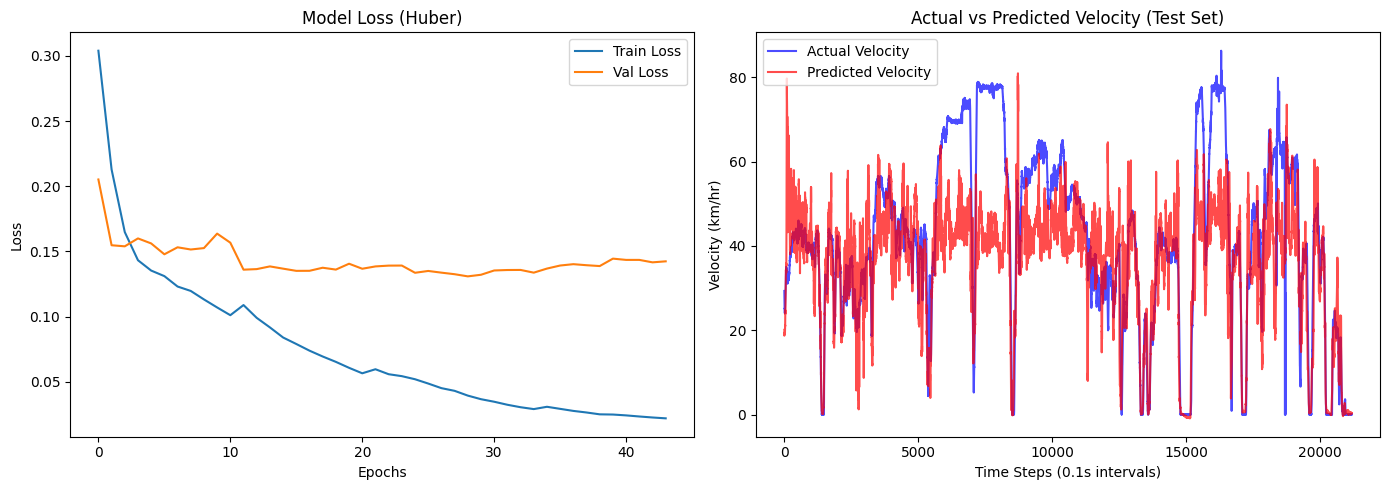

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber

# ==========================================
# 1. Load Data & Extract by Index
# ==========================================
s_data = pd.read_csv('/content/IO-VNBD/data_sync/S-Dataset/S-M.csv', encoding='latin1')
v_data = pd.read_csv('/content/IO-VNBD/data_sync/V-Dataset/V-M.csv', encoding='latin1')

y_raw = v_data.iloc[:, 4].values

acc_x = s_data.iloc[:, 9].values
acc_y = s_data.iloc[:, 10].values
acc_z = s_data.iloc[:, 11].values

grav_x = s_data.iloc[:, 12].values
grav_y = s_data.iloc[:, 13].values
grav_z = s_data.iloc[:, 14].values

gyro_yaw = s_data.iloc[:, 15].values
gyro_pitch = s_data.iloc[:, 16].values
gyro_roll = s_data.iloc[:, 17].values

orient_yaw = s_data.iloc[:, 21].values
orient_pitch = s_data.iloc[:, 22].values
orient_roll = s_data.iloc[:, 23].values

# ==========================================
# 2. Advanced Feature Engineering
# ==========================================
lin_acc_x = acc_x - grav_x
lin_acc_y = acc_y - grav_y
lin_acc_z = acc_z - grav_z

# Magnitudes
acc_mag = np.sqrt(lin_acc_x**2 + lin_acc_y**2 + lin_acc_z**2)
gyro_mag = np.sqrt(gyro_yaw**2 + gyro_pitch**2 + gyro_roll**2)

# NEW: Jerk (Derivative of Acceleration) - Detects pedal presses instantly!
jerk_x = np.gradient(lin_acc_x)
jerk_y = np.gradient(lin_acc_y)
jerk_z = np.gradient(lin_acc_z)

# Stack all 14 features into a 2D NumPy array
X_raw = np.column_stack((
    lin_acc_x, lin_acc_y, lin_acc_z, acc_mag,
    jerk_x, jerk_y, jerk_z,                   # <-- New Jerk Features
    gyro_yaw, gyro_pitch, gyro_roll, gyro_mag,
    orient_yaw, orient_pitch, orient_roll
))

# Smooth the sensor noise using a rolling mean
X_df = pd.DataFrame(X_raw)
X_smoothed = X_df.rolling(window=5, min_periods=1).mean().values

# ==========================================
# 3. Clean & Scale Data
# ==========================================
valid_mask = ~np.isnan(X_smoothed).any(axis=1) & ~np.isnan(y_raw)
X_clean = X_smoothed[valid_mask]
y_clean = y_raw[valid_mask]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_clean)
y_scaled = scaler_y.fit_transform(y_clean.reshape(-1, 1))

# ==========================================
# 4. Create Sequences (5 Seconds of Context)
# ==========================================
WINDOW_SIZE = 50

def create_sequences(data_x, data_y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data_x) - window_size):
        X_seq.append(data_x[i : i + window_size])
        y_seq.append(data_y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

# ==========================================
# 5. Build CNN-BiLSTM Model
# ==========================================
model = Sequential()

# NEW: 1D CNN Layer acts as a local feature extractor and noise filter
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))

# Bidirectional LSTM Layers
model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.3))

# Dense Output Layers
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1))

# NEW: Huber Loss is much more robust for time-series velocity prediction than MSE
model.compile(optimizer='adam', loss=Huber(), metrics=['mae'])
model.summary()

# ==========================================
# 6. Train with Callbacks
# ==========================================
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=80,              # Increased epochs since Huber loss takes longer to converge
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ==========================================
# 7. Evaluate and Plot Results
# ==========================================
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f"\nOptimized Test RMSE: {rmse:.2f} km/hr")
print(f"Optimized Test MAE: {mae:.2f} km/hr")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Huber)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true, label='Actual Velocity', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Velocity', color='red', alpha=0.7)
plt.title('Actual vs Predicted Velocity (Test Set)')
plt.xlabel('Time Steps (0.1s intervals)')
plt.ylabel('Velocity (km/hr)')
plt.legend()

plt.tight_layout()
plt.show()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 50, 128)   │     38,912 │ input_layer_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 50, 128)   │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 64)        │     41,216 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │      1,040 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ velocity_out        │ (None, 1)         │         17 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acceleration_out    │ (None, 1)         │         17 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 81,202 (317.20 KB)

 Trainable params: 81,202 (317.20 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - acceleration_out_loss: 0.9701 - loss: 1.1293 - velocity_out_loss: 0.6436 - velocity_out_mae: 0.5984 - val_acceleration_out_loss: 0.4752 - val_loss: 0.6948 - val_velocity_out_loss: 0.4569 - val_velocity_out_mae: 0.4838 - learning_rate: 0.0010
Epoch 2/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - acceleration_out_loss: 0.9138 - loss: 0.8463 - velocity_out_loss: 0.3889 - velocity_out_mae: 0.4681 - val_acceleration_out_loss: 0.4641 - val_loss: 0.6003 - val_velocity_out_loss: 0.3679 - val_velocity_out_mae: 0.4404 - learning_rate: 0.0010
Epoch 3/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - acceleration_out_loss: 0.8706 - loss: 0.7369 - velocity_out_loss: 0.3013 - velocity_out_mae: 0.4103 - val_acceleration_out_loss: 0.4725 - val_loss: 0.7114 - val_velocity_out_loss: 0.4749 - val_velocity_out_mae: 0.5063 - learning_rate: 0.0010
Epoch 4/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - acceleration_out_loss

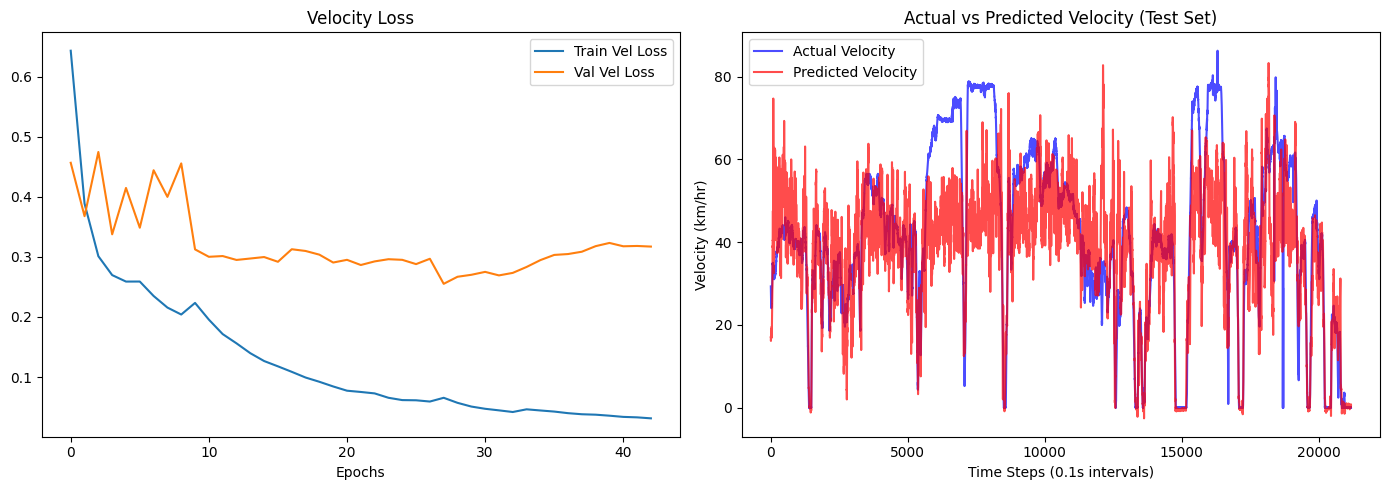

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# ==========================================
# 1. Load Data & Extract by Index
# ==========================================
s_data = pd.read_csv('/content/IO-VNBD/data_sync/S-Dataset/S-M.csv', encoding='latin1')
v_data = pd.read_csv('/content/IO-VNBD/data_sync/V-Dataset/V-M.csv', encoding='latin1')

y_vel_raw = v_data.iloc[:, 4].values

acc_x = s_data.iloc[:, 9].values
acc_y = s_data.iloc[:, 10].values
acc_z = s_data.iloc[:, 11].values

grav_x = s_data.iloc[:, 12].values
grav_y = s_data.iloc[:, 13].values
grav_z = s_data.iloc[:, 14].values

gyro_yaw = s_data.iloc[:, 15].values
gyro_pitch = s_data.iloc[:, 16].values
gyro_roll = s_data.iloc[:, 17].values

orient_yaw = s_data.iloc[:, 21].values
orient_pitch = s_data.iloc[:, 22].values
orient_roll = s_data.iloc[:, 23].values

# ==========================================
# 2. Feature Engineering
# ==========================================
lin_acc_x = acc_x - grav_x
lin_acc_y = acc_y - grav_y
lin_acc_z = acc_z - grav_z

acc_mag = np.sqrt(lin_acc_x**2 + lin_acc_y**2 + lin_acc_z**2)
gyro_mag = np.sqrt(gyro_yaw**2 + gyro_pitch**2 + gyro_roll**2)

X_raw = np.column_stack((
    lin_acc_x, lin_acc_y, lin_acc_z, acc_mag,
    gyro_yaw, gyro_pitch, gyro_roll, gyro_mag,
    orient_yaw, orient_pitch, orient_roll
))

# Smooth sensor noise
X_df = pd.DataFrame(X_raw)
X_smoothed = X_df.rolling(window=5, min_periods=1).mean().values

# ==========================================
# 3. NEW: Calculate True Acceleration (Target 2)
# ==========================================
# Velocity is at 10Hz (0.1s intervals). Acceleration is the change in velocity.
# Acc = (V[t] - V[t-1]) / 0.1
y_acc_raw = np.gradient(y_vel_raw) * 10.0

# ==========================================
# 4. Clean & Scale Data
# ==========================================
valid_mask = ~np.isnan(X_smoothed).any(axis=1) & ~np.isnan(y_vel_raw) & ~np.isnan(y_acc_raw)
X_clean = X_smoothed[valid_mask]
y_vel_clean = y_vel_raw[valid_mask]
y_acc_clean = y_acc_raw[valid_mask]

scaler_X = StandardScaler()
scaler_vel = StandardScaler()
scaler_acc = StandardScaler()

X_scaled = scaler_X.fit_transform(X_clean)
y_vel_scaled = scaler_vel.fit_transform(y_vel_clean.reshape(-1, 1))
y_acc_scaled = scaler_acc.fit_transform(y_acc_clean.reshape(-1, 1))

# ==========================================
# 5. Create Sequences
# ==========================================
WINDOW_SIZE = 50

def create_sequences(data_x, data_y_vel, data_y_acc, window_size):
    X_seq, y_vel_seq, y_acc_seq = [], [], []
    for i in range(len(data_x) - window_size):
        X_seq.append(data_x[i : i + window_size])
        y_vel_seq.append(data_y_vel[i + window_size])
        y_acc_seq.append(data_y_acc[i + window_size])
    return np.array(X_seq), np.array(y_vel_seq), np.array(y_acc_seq)

X_seq, y_vel_seq, y_acc_seq = create_sequences(X_scaled, y_vel_scaled, y_acc_scaled, WINDOW_SIZE)

split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_vel_train, y_vel_test = y_vel_seq[:split_index], y_vel_seq[split_index:]
y_acc_train, y_acc_test = y_acc_seq[:split_index], y_acc_seq[split_index:]

# ==========================================
# 6. Build Multi-Task Model
# ==========================================
# Input Layer
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Shared LSTM Layers (Learns the physics of the car)
lstm1 = Bidirectional(LSTM(64, return_sequences=True))(input_layer)
lstm1_drop = Dropout(0.2)(lstm1)

lstm2 = Bidirectional(LSTM(32, return_sequences=False))(lstm1_drop)
shared_dense = Dense(16, activation='relu')(lstm2)

# Branch 1: Velocity Prediction
vel_out = Dense(1, name='velocity_out')(shared_dense)

# Branch 2: Acceleration Prediction (Forces the network to learn physics)
acc_out = Dense(1, name='acceleration_out')(shared_dense)

model = Model(inputs=input_layer, outputs=[vel_out, acc_out])

# Compile with two losses. We weight velocity higher because that's our main goal.
model.compile(
    optimizer='adam',
    loss={'velocity_out': 'mse', 'acceleration_out': 'mse'},
    loss_weights={'velocity_out': 1.0, 'acceleration_out': 0.5},
    metrics={'velocity_out': 'mae'}
)
model.summary()

# ==========================================
# 7. Train the Model
# ==========================================
# ==========================================
# 7. Train the Model
# ==========================================
# FIX: Added mode='min' to both callbacks
reduce_lr = ReduceLROnPlateau(
    monitor='val_velocity_out_loss',
    factor=0.5,
    patience=5,
    min_lr=0.0001,
    verbose=1,
    mode='min'  # <--- Added this
)

early_stop = EarlyStopping(
    monitor='val_velocity_out_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    mode='min'  # <--- Added this
)

print("Starting training...")
history = model.fit(
    X_train,
    {'velocity_out': y_vel_train, 'acceleration_out': y_acc_train},
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)
# ==========================================
# 8. Evaluate and Plot
# ==========================================
# Predict returns a list of two arrays: [vel_pred, acc_pred]
predictions = model.predict(X_test)
y_pred_vel_scaled = predictions[0]

y_pred_vel = scaler_vel.inverse_transform(y_pred_vel_scaled)
y_true_vel = scaler_vel.inverse_transform(y_vel_test)

rmse = np.sqrt(mean_squared_error(y_true_vel, y_pred_vel))
mae = mean_absolute_error(y_true_vel, y_pred_vel)
print(f"\nMulti-Task Test RMSE: {rmse:.2f} km/hr")
print(f"Multi-Task Test MAE: {mae:.2f} km/hr")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['velocity_out_loss'], label='Train Vel Loss')
plt.plot(history.history['val_velocity_out_loss'], label='Val Vel Loss')
plt.title('Velocity Loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true_vel, label='Actual Velocity', color='blue', alpha=0.7)
plt.plot(y_pred_vel, label='Predicted Velocity', color='red', alpha=0.7)
plt.title('Actual vs Predicted Velocity (Test Set)')
plt.xlabel('Time Steps (0.1s intervals)')
plt.ylabel('Velocity (km/hr)')
plt.legend()

plt.tight_layout()
plt.show()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 50, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 32)         │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 50, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 50, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.3472 - mae: 0.6817 - val_loss: 0.2241 - val_mae: 0.5282 - learning_rate: 0.0010
Epoch 2/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2723 - mae: 0.5943 - val_loss: 0.1778 - val_mae: 0.4621 - learning_rate: 0.0010
Epoch 3/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2011 - mae: 0.4992 - val_loss: 0.1788 - val_mae: 0.4630 - learning_rate: 0.0010
Epoch 4/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1729 - mae: 0.4628 - val_loss: 0.1577 - val_mae: 0.4285 - learning_rate: 0.0010
Epoch 5/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1575 - mae: 0.4363 - val_loss: 0.1689 - val_mae: 0.4434 - learning_rate: 0.0010
Epoch 6/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1489 - mae: 0.4248 - val_loss: 0.1612 - val_mae: 0.4310 - learning_rate: 0.0010
Epoch 7/80
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1413 - mae: 0.4137 - val_loss: 0.1495 - val_mae: 

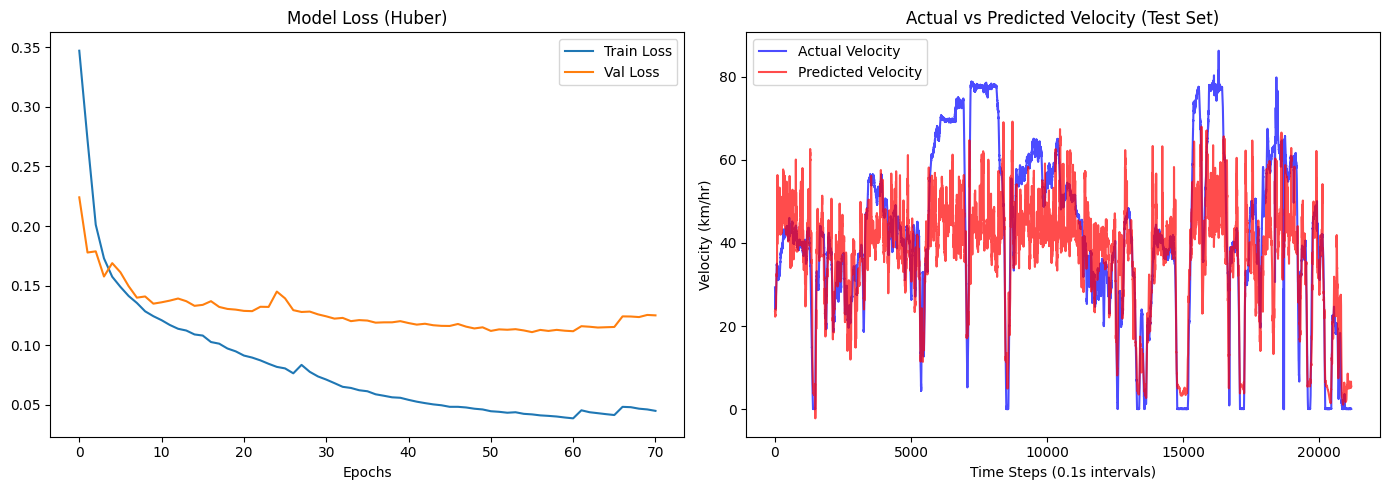

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, Add, Activation, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber

# ==========================================
# 1. Load Data & Extract by Index
# ==========================================
s_data = pd.read_csv('/content/IO-VNBD/data_sync/S-Dataset/S-M.csv', encoding='latin1')
v_data = pd.read_csv('/content/IO-VNBD/data_sync/V-Dataset/V-M.csv', encoding='latin1')


y_raw = v_data.iloc[:, 4].values

acc_x = s_data.iloc[:, 9].values
acc_y = s_data.iloc[:, 10].values
acc_z = s_data.iloc[:, 11].values

grav_x = s_data.iloc[:, 12].values
grav_y = s_data.iloc[:, 13].values
grav_z = s_data.iloc[:, 14].values

gyro_yaw = s_data.iloc[:, 15].values
gyro_pitch = s_data.iloc[:, 16].values
gyro_roll = s_data.iloc[:, 17].values

orient_yaw = s_data.iloc[:, 21].values
orient_pitch = s_data.iloc[:, 22].values
orient_roll = s_data.iloc[:, 23].values

# ==========================================
# 2. Feature Engineering
# ==========================================
lin_acc_x = acc_x - grav_x
lin_acc_y = acc_y - grav_y
lin_acc_z = acc_z - grav_z

acc_mag = np.sqrt(lin_acc_x**2 + lin_acc_y**2 + lin_acc_z**2)
gyro_mag = np.sqrt(gyro_yaw**2 + gyro_pitch**2 + gyro_roll**2)

# NEW: Jerk (Crucial for TCN to detect sudden pedal presses)
jerk_x = np.gradient(lin_acc_x)
jerk_y = np.gradient(lin_acc_y)
jerk_z = np.gradient(lin_acc_z)

X_raw = np.column_stack((
    lin_acc_x, lin_acc_y, lin_acc_z, acc_mag,
    jerk_x, jerk_y, jerk_z,
    gyro_yaw, gyro_pitch, gyro_roll, gyro_mag,
    orient_yaw, orient_pitch, orient_roll
))

# NEW: Very light smoothing (window=3) just to remove pure sensor static,
# but preserves the sharp curves so the TCN can see them.
X_df = pd.DataFrame(X_raw)
X_smoothed = X_df.rolling(window=3, min_periods=1).mean().values

# ==========================================
# 3. Clean & Scale Data
# ==========================================
valid_mask = ~np.isnan(X_smoothed).any(axis=1) & ~np.isnan(y_raw)
X_clean = X_smoothed[valid_mask]
y_clean = y_raw[valid_mask]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_clean)
y_scaled = scaler_y.fit_transform(y_clean.reshape(-1, 1))

# ==========================================
# 4. Create Sequences
# ==========================================
WINDOW_SIZE = 50

def create_sequences(data_x, data_y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data_x) - window_size):
        X_seq.append(data_x[i : i + window_size])
        y_seq.append(data_y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

# ==========================================
# 5. Build Dilated TCN (Temporal Convolutional Network)
# ==========================================
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

# TCN Block 1 (Dilation 1 - Looks at immediate local changes)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=1, activation='relu')(input_layer)
x = Dropout(0.1)(x)

# TCN Block 2 (Dilation 2 - Expands view to 4 steps)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=2, activation='relu')(x)
x = Dropout(0.1)(x)

# TCN Block 3 (Dilation 4 - Expands view to 8 steps)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=4, activation='relu')(x)
x = Dropout(0.1)(x)

# TCN Block 4 (Dilation 8 - Expands view to 16 steps)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=8, activation='relu')(x)
x = Dropout(0.1)(x)

# TCN Block 5 (Dilation 16 - Expands view to 32 steps)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=16, activation='relu')(x)
x = Dropout(0.1)(x)

# Global Pooling merges all time-steps into a single feature vector
x = GlobalAveragePooling1D()(x)

# Dense reasoning layers
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)

# Output
output_layer = Dense(1)(x)

model = Model(inputs=input_layer, outputs=output_layer)

# Huber loss ignores sensor spikes, Adam optimizer
model.compile(optimizer='adam', loss=Huber(), metrics=['mae'])
model.summary()

# ==========================================
# 6. Train the Model
# ==========================================
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001, verbose=1, mode='min')
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1, mode='min')

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ==========================================
# 7. Evaluate and Plot
# ==========================================
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f"\nTCN Test RMSE: {rmse:.2f} km/hr")
print(f"TCN Test MAE: {mae:.2f} km/hr")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Huber)')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true, label='Actual Velocity', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Velocity', color='red', alpha=0.7)
plt.title('Actual vs Predicted Velocity (Test Set)')
plt.xlabel('Time Steps (0.1s intervals)')
plt.ylabel('Velocity (km/hr)')
plt.legend()

plt.tight_layout()
plt.show()

Starting training...
Epoch 1/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.1327 - mae: 0.3900 - val_loss: 0.0482 - val_mae: 0.2455 - learning_rate: 0.0010
Epoch 2/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0532 - mae: 0.2386 - val_loss: 0.0397 - val_mae: 0.2207 - learning_rate: 0.0010
Epoch 3/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0466 - mae: 0.2219 - val_loss: 0.0533 - val_mae: 0.2611 - learning_rate: 0.0010
Epoch 4/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0376 - mae: 0.1982 - val_loss: 0.0470 - val_mae: 0.2414 - learning_rate: 0.0010
Epoch 5/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0365 - mae: 0.1921 - val_loss: 0.0951 - val_mae: 0.3375 - learning_rate: 0.0010
Epoch 6/60
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0299 - mae: 0.1798 - val_loss: 0.0396 - val_mae: 0.2205 - learning_rate: 0.0010
Epoch 7/60
1049/1060 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0247 - mae: 0.1545
Epoch 7: ReduceLROnPlateau redu

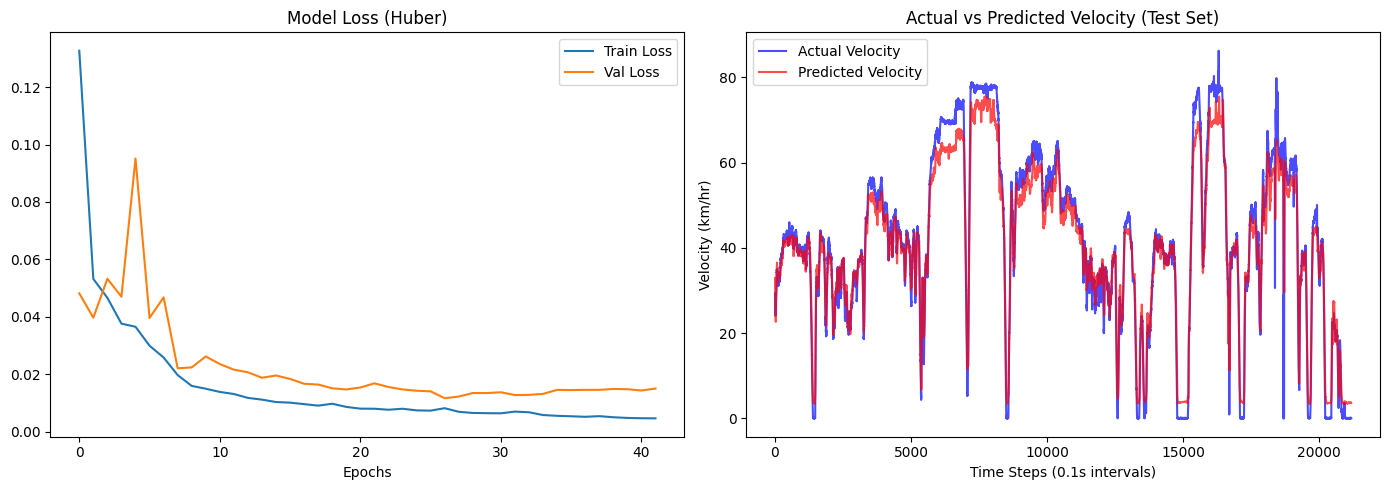

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.losses import Huber

# ==========================================
# 1. Load Data & Extract by Index
# ==========================================
s_data = pd.read_csv('/content/IO-VNBD/data_sync/S-Dataset/S-M.csv', encoding='latin1')
v_data = pd.read_csv('/content/IO-VNBD/data_sync/V-Dataset/V-M.csv', encoding='latin1')


y_raw = v_data.iloc[:, 4].values

acc_x = s_data.iloc[:, 9].values
acc_y = s_data.iloc[:, 10].values
acc_z = s_data.iloc[:, 11].values

grav_x = s_data.iloc[:, 12].values
grav_y = s_data.iloc[:, 13].values
grav_z = s_data.iloc[:, 14].values

gyro_yaw = s_data.iloc[:, 15].values
gyro_pitch = s_data.iloc[:, 16].values
gyro_roll = s_data.iloc[:, 17].values

orient_yaw = s_data.iloc[:, 21].values
orient_pitch = s_data.iloc[:, 22].values
orient_roll = s_data.iloc[:, 23].values

# ==========================================
# 2. Feature Engineering
# ==========================================
lin_acc_x = acc_x - grav_x
lin_acc_y = acc_y - grav_y
lin_acc_z = acc_z - grav_z

acc_mag = np.sqrt(lin_acc_x**2 + lin_acc_y**2 + lin_acc_z**2)
gyro_mag = np.sqrt(gyro_yaw**2 + gyro_pitch**2 + gyro_roll**2)

jerk_x = np.gradient(lin_acc_x)
jerk_y = np.gradient(lin_acc_y)
jerk_z = np.gradient(lin_acc_z)

# NEW: Autoregressive Feature (Previous Velocity)
# Shift the velocity array by 1 so that at time 't', the network sees the velocity at 't-1'
y_prev = np.roll(y_raw, 1)
y_prev[0] = y_raw[0] # Fix the first rolled-over value

X_raw = np.column_stack((
    lin_acc_x, lin_acc_y, lin_acc_z, acc_mag,
    jerk_x, jerk_y, jerk_z,
    gyro_yaw, gyro_pitch, gyro_roll, gyro_mag,
    orient_yaw, orient_pitch, orient_roll,
    y_prev  # <--- The Mathematical Anchor
))

X_df = pd.DataFrame(X_raw)
X_smoothed = X_df.rolling(window=3, min_periods=1).mean().values

# ==========================================
# 3. Clean & Scale Data
# ==========================================
valid_mask = ~np.isnan(X_smoothed).any(axis=1) & ~np.isnan(y_raw)
X_clean = X_smoothed[valid_mask]
y_clean = y_raw[valid_mask]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_clean)
y_scaled = scaler_y.fit_transform(y_clean.reshape(-1, 1))

# ==========================================
# 4. Create Sequences
# ==========================================
WINDOW_SIZE = 50

def create_sequences(data_x, data_y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data_x) - window_size):
        X_seq.append(data_x[i : i + window_size])
        y_seq.append(data_y[i + window_size])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split_index = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

# ==========================================
# 5. Build Anchored TCN Model
# ==========================================
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Dilated TCN Layers
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=1, activation='relu')(input_layer)
x = Dropout(0.1)(x)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=2, activation='relu')(x)
x = Dropout(0.1)(x)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=4, activation='relu')(x)
x = Dropout(0.1)(x)
x = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=8, activation='relu')(x)
x = Dropout(0.1)(x)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(16, activation='relu')(x)

output_layer = Dense(1)(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss=Huber(), metrics=['mae'])

# ==========================================
# 6. Train the Model
# ==========================================
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001, verbose=1, mode='min')
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1, mode='min')

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=64,
    validation_split=0.2,
    shuffle=False,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

# ==========================================
# 7. Evaluate and Plot
# ==========================================
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f"\nAnchored TCN Test RMSE: {rmse:.2f} km/hr")
print(f"Anchored TCN Test MAE: {mae:.2f} km/hr")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (Huber)')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(y_true, label='Actual Velocity', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Velocity', color='red', alpha=0.7)
plt.title('Actual vs Predicted Velocity (Test Set)')
plt.xlabel('Time Steps (0.1s intervals)')
plt.ylabel('Velocity (km/hr)')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
import joblib
# Save the model
model.save('imu_velocity_predictor.h5')

# Save the scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']


--- Evaluating: /content/IO-VNBD/data_sync/val/S-Y1.csv & /content/IO-VNBD/data_sync/val/V-Y1.csv ---
Validation RMSE: 4.93 km/hr
Validation MAE: 3.75 km/hr


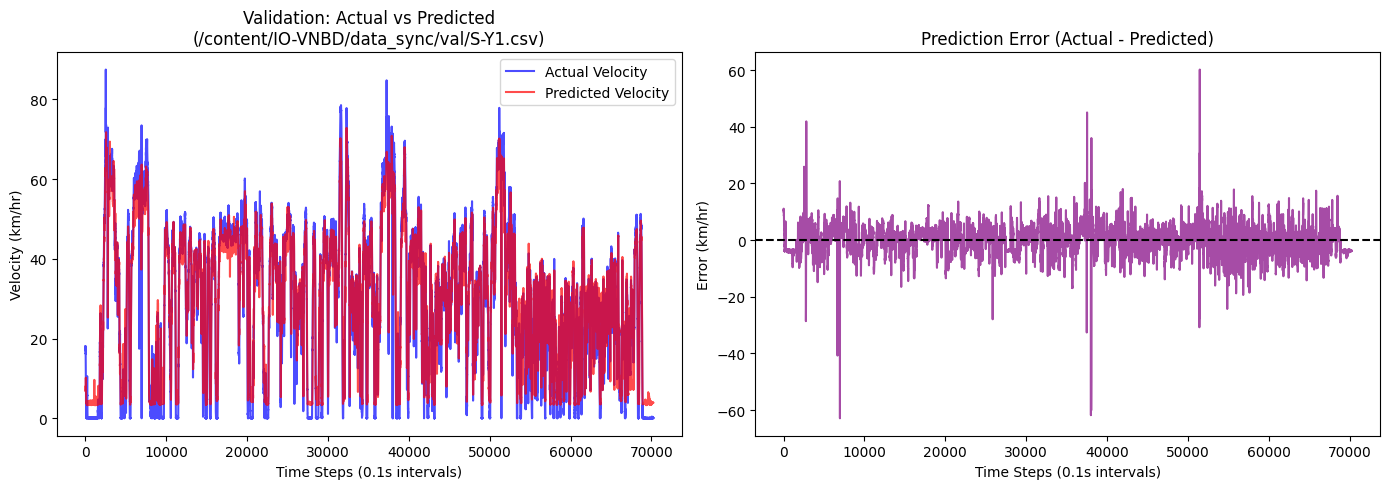

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==========================================
# 1. Define the Evaluation Function
# ==========================================
# Note: This assumes 'model', 'scaler_X', and 'scaler_y' are already in your memory
# from the previous training step.

def evaluate_new_data(s_file, v_file, model, scaler_X, scaler_y, window_size=50):
    print(f"\n--- Evaluating: {s_file} & {v_file} ---")

    # Load new data
    s_data = pd.read_csv(s_file, encoding='latin1')
    v_data = pd.read_csv(v_file, encoding='latin1')

    # Extract by Index (Must match the training data exactly)
    y_raw = v_data.iloc[:, 4].values

    acc_x = s_data.iloc[:, 9].values
    acc_y = s_data.iloc[:, 10].values
    acc_z = s_data.iloc[:, 11].values

    grav_x = s_data.iloc[:, 12].values
    grav_y = s_data.iloc[:, 13].values
    grav_z = s_data.iloc[:, 14].values

    gyro_yaw = s_data.iloc[:, 15].values
    gyro_pitch = s_data.iloc[:, 16].values
    gyro_roll = s_data.iloc[:, 17].values

    orient_yaw = s_data.iloc[:, 21].values
    orient_pitch = s_data.iloc[:, 22].values
    orient_roll = s_data.iloc[:, 23].values

    # Feature Engineering (Same as training)
    lin_acc_x = acc_x - grav_x
    lin_acc_y = acc_y - grav_y
    lin_acc_z = acc_z - grav_z

    acc_mag = np.sqrt(lin_acc_x**2 + lin_acc_y**2 + lin_acc_z**2)
    gyro_mag = np.sqrt(gyro_yaw**2 + gyro_pitch**2 + gyro_roll**2)

    jerk_x = np.gradient(lin_acc_x)
    jerk_y = np.gradient(lin_acc_y)
    jerk_z = np.gradient(lin_acc_z)

    # Autoregressive Anchor (Previous Velocity)
    y_prev = np.roll(y_raw, 1)
    y_prev[0] = y_raw[0]

    X_raw = np.column_stack((
        lin_acc_x, lin_acc_y, lin_acc_z, acc_mag,
        jerk_x, jerk_y, jerk_z,
        gyro_yaw, gyro_pitch, gyro_roll, gyro_mag,
        orient_yaw, orient_pitch, orient_roll,
        y_prev
    ))

    # Smooth (Same as training)
    X_df = pd.DataFrame(X_raw)
    X_smoothed = X_df.rolling(window=3, min_periods=1).mean().values

    # Clean NaNs
    valid_mask = ~np.isnan(X_smoothed).any(axis=1) & ~np.isnan(y_raw)
    X_clean = X_smoothed[valid_mask]
    y_clean = y_raw[valid_mask]

    # Scale using the TRAINED scalers
    X_scaled = scaler_X.transform(X_clean)
    y_scaled = scaler_y.transform(y_clean.reshape(-1, 1))

    # Create Sequences
    def create_sequences(data_x, data_y, window_size):
        X_seq, y_seq = [], []
        for i in range(len(data_x) - window_size):
            X_seq.append(data_x[i : i + window_size])
            y_seq.append(data_y[i + window_size])
        return np.array(X_seq), np.array(y_seq)

    X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size)

    # Predict
    y_pred_scaled = model.predict(X_seq, verbose=0)

    # Inverse transform
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_seq)

    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"Validation RMSE: {rmse:.2f} km/hr")
    print(f"Validation MAE: {mae:.2f} km/hr")

    # Plot Results
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(y_true, label='Actual Velocity', color='blue', alpha=0.7)
    plt.plot(y_pred, label='Predicted Velocity', color='red', alpha=0.7)
    plt.title(f'Validation: Actual vs Predicted\n({s_file})')
    plt.xlabel('Time Steps (0.1s intervals)')
    plt.ylabel('Velocity (km/hr)')
    plt.legend()

    # Plot Error (Residuals)
    plt.subplot(1, 2, 2)
    error = y_true.flatten() - y_pred.flatten()
    plt.plot(error, color='purple', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title('Prediction Error (Actual - Predicted)')
    plt.xlabel('Time Steps (0.1s intervals)')
    plt.ylabel('Error (km/hr)')

    plt.tight_layout()
    plt.show()

    return rmse, mae

# ==========================================
# 2. Run Validation on New Files
# ==========================================

# Replace these with the names of your new CSV files
NEW_S_FILE = '/content/IO-VNBD/data_sync/val/S-Y1.csv'
NEW_V_FILE = '/content/IO-VNBD/data_sync/val/V-Y1.csv'

# Run the function
val_rmse, val_mae = evaluate_new_data(
    s_file=NEW_S_FILE,
    v_file=NEW_V_FILE,
    model=model,           # Your trained Keras model
    scaler_X=scaler_X,     # Your fitted feature scaler
    scaler_y=scaler_y      # Your fitted target scaler
)